In [28]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf 
from keras.layers import Dense,Input
from keras.models import Sequential
from keras.losses import mean_squared_error,binary_crossentropy
from keras.activations import sigmoid
from lab_neurons_utils import plt_prob_1d,sigmoidnp,plt_linear,plt_logistic
from lab_utils_common import dlc

import logging
logging.getLogger('tensorflow').setLevel(logging.ERROR)
tf.autograph.set_verbosity(0)

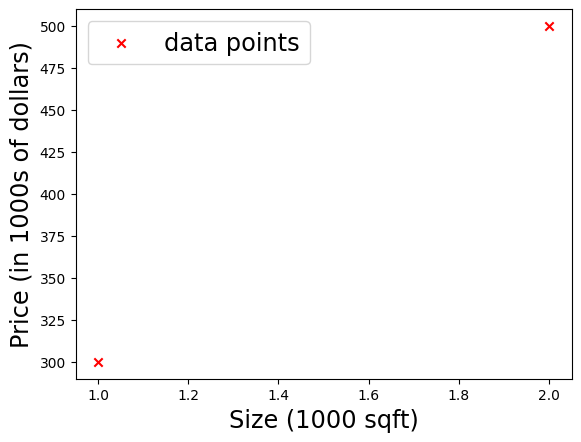

In [29]:
# neuron without activation- regression/linear model

x_train=np.array([[1.0],[2.0]], dtype=np.float32)
y_train=np.array([[300.0],[500.0]],dtype=np.float32)
fig,ax=plt.subplots(1,1)
ax.scatter(x_train,y_train,marker='x',c='r',label="data points")
ax.legend(fontsize='xx-large')
ax.set_ylabel('Price (in 1000s of dollars)', fontsize='xx-large')
ax.set_xlabel('Size (1000 sqft)', fontsize='xx-large')
plt.show()

In [30]:
linear_layer=Dense(units=1,activation='linear',)
linear_layer.get_weights()

[]

In [31]:
a1=linear_layer(x_train[0].reshape(1,1))
print(a1)

tf.Tensor([[0.37]], shape=(1, 1), dtype=float32)


In [32]:
w,b=linear_layer.get_weights()
print(f'w= {w}, b= {b}')

w= [[0.37]], b= [0.]


In [33]:
set_w=np.array([[200]])
set_b=np.array([100])
linear_layer.set_weights([set_w,set_b])
print(linear_layer.get_weights())

[array([[200.]], dtype=float32), array([100.], dtype=float32)]


In [34]:
a1=linear_layer(x_train[0].reshape(1,1))
print(a1)
alin=np.dot(set_w,x_train[0].reshape(1,1))+set_b
print(alin)

tf.Tensor([[300.]], shape=(1, 1), dtype=float32)
[[300.]]


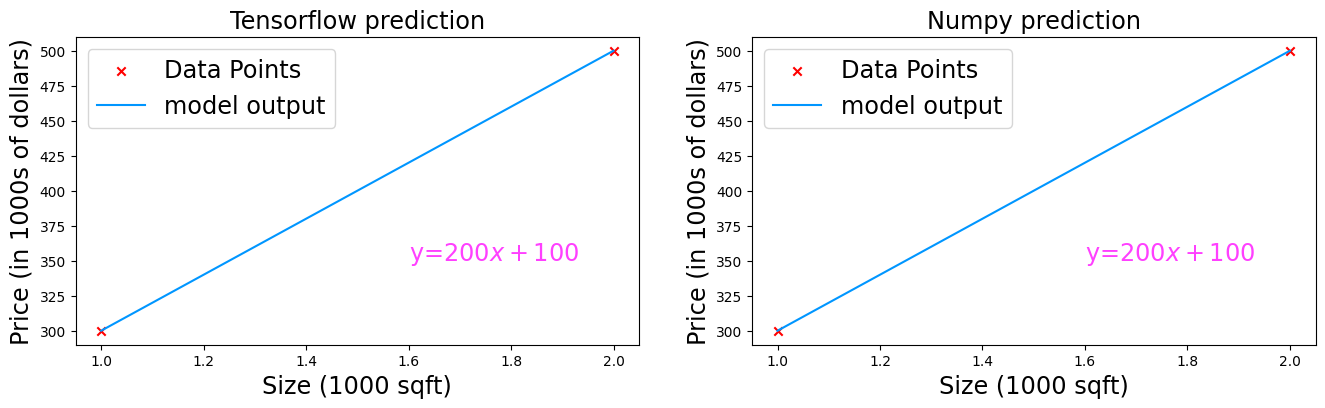

In [35]:
prediction_tf=linear_layer(x_train)
prediction_np=np.dot(x_train,set_w)+set_b
plt_linear(x_train,y_train,prediction_tf,prediction_np)

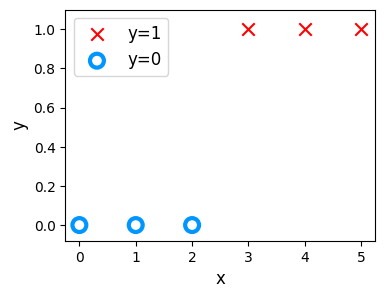

In [36]:
# neurons with sigmoid activation
x_train=np.array([0,1,2,3,4,5],dtype=np.float32).reshape(-1,1)
y_train=np.array([0,0,0,1,1,1],dtype=np.float32).reshape(-1,1)

pos=y_train==1
neg=y_train==0

fig,ax=plt.subplots(1,1,figsize=(4,3))
ax.scatter(x_train[pos],y_train[pos],marker='x',s=80,c='red',label='y=1')
ax.scatter(x_train[neg],y_train[neg],marker='o',s=100,label='y=0',facecolors='none',
           edgecolors=dlc['dlblue'],lw=3)
ax.set_ylim(-0.08,1.1)
ax.set_ylabel('y',fontsize=12)
ax.set_xlabel('x',fontsize=12)
ax.legend(fontsize=12)
plt.show()


In [37]:
#logistic neuron
'''
This section will create a Tensorflow Model that contains our logistic layer to demonstrate an alternate method of creating models. Tensorflow is most often used to create multi-layer models. The Sequential model is a convenient means of constructing these models.
'''
model=Sequential(
    [
        Dense(1,input_dim=1,activation='sigmoid',name='l1')
    ]
)
model.summary()

c:\Users\jyoti\OneDrive\Desktop\python\neural_networks\tf_env\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ l1 (Dense)                      │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2 (8.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

In [39]:
logistic_layer=model.get_layer('l1')
print(logistic_layer)
w,b=logistic_layer.get_weights()
print(w,b)
print(w.shape,b.shape)

<Dense name=l1, built=True>
[[-0.34]] [0.]
(1, 1) (1,)


In [40]:
# lets set the parameters
set_w=np.array([[2]])
set_b=np.array([-4.5])
logistic_layer.set_weights([set_w,set_b])
print(logistic_layer.get_weights())

[array([[2.]], dtype=float32), array([-4.5], dtype=float32)]


In [42]:
a1=model.predict(x_train[0].reshape(1,1))
print(a1)
alog=sigmoidnp(np.dot(set_w,x_train[0].reshape(1,1))+set_b)
print(alog)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
[[0.01]]
[[0.01]]


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━

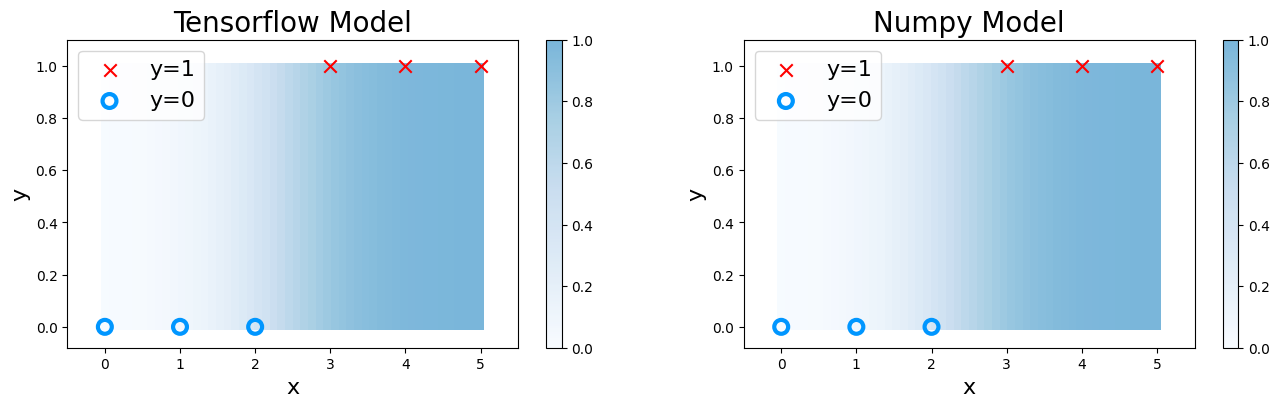

In [43]:
plt_logistic(x_train,y_train,model,set_w,set_b,pos,neg)